In [1]:
# INTRODUCTION
'''This project aims to analyze medical insurance costs and identify key factors that influence high healthcare expenses. 
Using regression and classification models, I will aim to predict individual charges and categorize high-risk individuals'''

#DATA CLEANING - (i) loading and previewing data

import pandas as pd
import numpy as np
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
#DATA CLEANING - (ii) checking details of data

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
#DATA CLEANING - (iii) removing duplicates and null

df.isnull().sum() # no missing values found
df.duplicated().sum() # 1 duplicate found
df = df.drop_duplicates()
df.duplicated().sum() # no more duplicates (yay!)

np.int64(0)

In [3]:
#DATA CLEANING - (iv) encoding (categorical variables are being converted into numerical using one-hot encoding)

df = pd.get_dummies(df,drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [4]:
#DATA CLEANING - (v) scaling (numerical features are being standardized using StandardScaler so that they have a mean of 0 and standard dev of 1 to make sure all these feature contribute equally to model training)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['age','bmi', 'children'] # decided not to scale 'charges' column since its a target variable y and not input feature(x)
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,16884.92400,False,True,False,False,True
1,-1.509965,0.509621,-0.078767,1725.55230,True,False,False,True,False
2,-0.797954,0.383307,1.580926,4449.46200,True,False,False,True,False
3,-0.441948,-1.305531,-0.908614,21984.47061,True,False,True,False,False
4,-0.513149,-0.292556,-0.908614,3866.85520,True,False,True,False,False


In [6]:
#-----Data Description----'''

'''The dataset used for this project is the Medical Cost Personal Dataset. 
This dataset has information about individuals and their medical insurance costs.
The dataset has the following variables:

age: Age of the individual (numerical)
sex: Gender of the individual (categorical: male/female)
bmi: Body Mass Index, a measure of body fat based on height and weight (numerical)
children: Number of dependents covered by insurance (numerical, discrete)
smoker: Smoking status (categorical: yes/no)
region: Residential area in the US (categorical: northeast, northwest, southeast, southwest)
charges: Individual medical costs billed by health insurance (numerical, continuous)

The purpose of this project is to perform regression and classification tasks for the medical insurance costs'''


'The dataset used for this project is the Medical Cost Personal Dataset. \nThis dataset has information about individuals and their medical insurance costs.\nThe dataset has the following variables:\n\nage: Age of the individual (numerical)\nsex: Gender of the individual (categorical: male/female)\nbmi: Body Mass Index, a measure of body fat based on height and weight (numerical)\nchildren: Number of dependents covered by insurance (numerical, discrete)\nsmoker: Smoking status (categorical: yes/no)\nregion: Residential area in the US (categorical: northeast, northwest, southeast, southwest)\ncharges: Individual medical costs billed by health insurance (numerical, continuous)\n\nThe purpose of this project is to perform regression and classification tasks for the medical insurance costs'

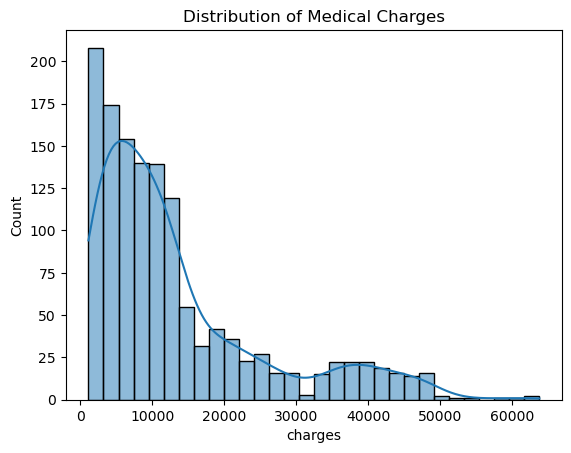

In [5]:
#-----Exploratory Data Analysis----

#Plot 1- Distribution of Charges
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

# output analysis: distribution of medical charges is right-skewed, which shows that a lot of individuals has lower charges while few incur higher coster

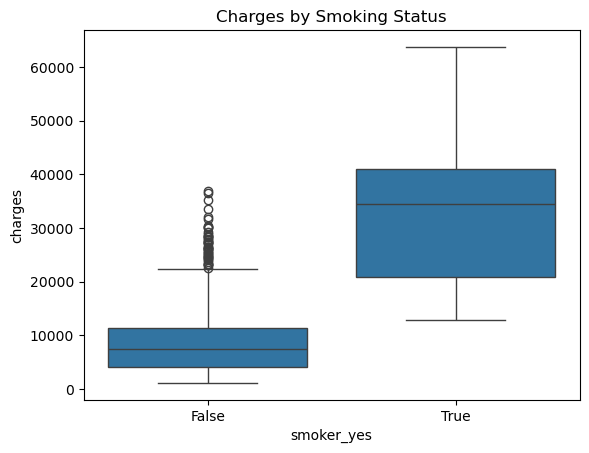

In [6]:
#Plot 2- Charges vs Smoker

sns.boxplot(x='smoker_yes',y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

#output analysis: Smokers contribute significantly to higher medical charges compared to non-smokers

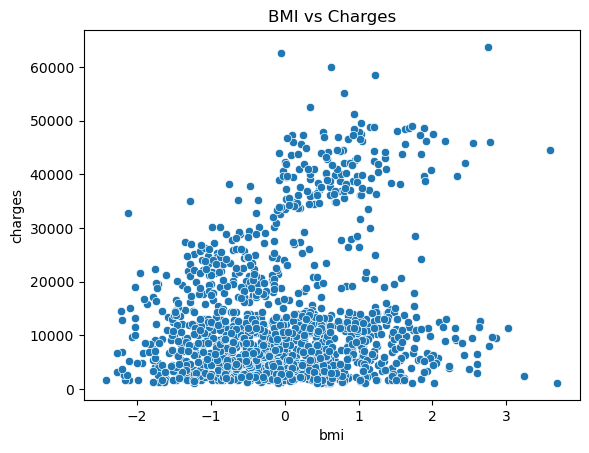

In [7]:
#Plot 3- BMI vs Charges

sns.scatterplot(x='bmi',y='charges',data=df)
plt.title("BMI vs Charges")
plt.show()

#output analysis: plot shows a positive relationship between BMI and medical charges which shows that higher BMI leads to increased costs.

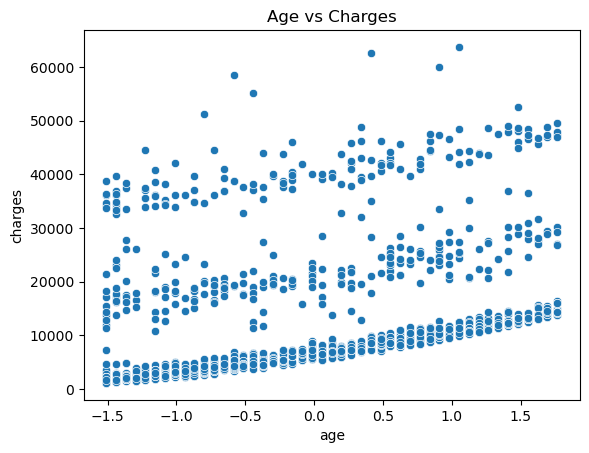

In [8]:
#Plot 4- Age vs Charges

sns.scatterplot(x='age',y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

#output analysis: Medical charges tend to increase with age which shows that older people might need more healthcare servicess

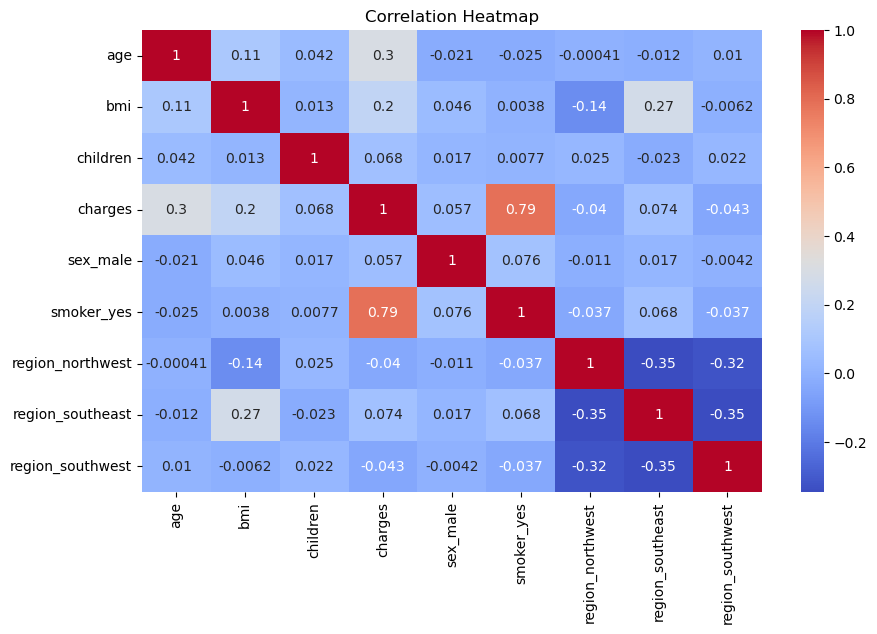

In [9]:
#Plot 5- Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#output analsyis: the heatmap shows significant correlation between smoking and charges, moderate correlation between age and BMI which further confirms previous insights!

In [10]:
 #-----Feature Engineering----

#BMI cartegory
df['bmi_category'] = pd.cut(df['bmi'],bins=[0, 18.5, 25, 30, 100], labels=['underweight', 'normal','overweight','obese'])
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)


In [11]:
#Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['young', 'middle', 'senior'])
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

In [12]:
#Smoker x BMI Interaction 

df['smoker_bmi'] = df['smoker_yes'] * df['bmi']
#An interaction term between smoking status and BMI was created to capture combined health risks.

In [13]:
#High Cost Indicator(for classification)

df['high_cost'] = (df['charges'] > df['charges'].median()).astype(int)
##A binary variable was created to classify individuals into high-cost and low-cost groups based on the median charge

In [14]:
#Family Size

df['family_size'] = df['children']+1
#Family size was created to represent total dependents, which may influence insurance costs.

In [27]:
#-----Modeling----

'''Starting with developing both regression and classification models to perform these tasks:
Regression models to predict the continuous values of insurance charges
Classification models to classify individuals based on high or low insurance charges
*also using regularization methods to control the complexity of the models and assess the bias-variance tradeoff'''

X = df.drop(columns=['charges', 'high_cost']) # output y ~ charges, high cost, x predictor ~age, bmi, smoker,etc.
y_reg = df['charges'] #regression target
y_clf = df['high_cost'] #classification target


#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [19]:
#Regression models

X = df.drop(columns=['charges', 'high_cost'])
y_reg = df['charges']

#linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)

#Ridge regression
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train_reg)
y_pred_ridge = ridge.predict(X_test)

#Lasso regreesiion
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train_reg)
y_pred_lasso = lasso.predict(X_test)

In [28]:
#Evaluating Regression
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_reg(y_true, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print("------")

evaluate_reg(y_test_reg, y_pred_lr)
evaluate_reg(y_test_reg, y_pred_ridge)
evaluate_reg(y_test_reg, y_pred_lasso)

#evaluating RMSE
#output analysis: similar R^2 values for linear, ridge and lasso regression means that the model did not as it is suffer from overfitting, regularization did not improve model performance significant
# model has overall abbout 86% variation in medical charges


RMSE: 4573.807686290386
R2: 0.8652503208873076
------
RMSE: 4571.171601341596
R2: 0.8654056003670527
------
RMSE: 4573.793158468412
R2: 0.8652511768989175
------


In [21]:
#classification models

#logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_clf)

y_pred_log = log_reg.predict(X_test)

#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train_clf)

y_pred_rf = rf.predict(X_test)


In [29]:
#Evaluating Classification
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print(classification_report(y_test_clf, y_pred_log))

print("Random Forest Accuracy:", accuracy_score(y_test_clf, y_pred_rf))
print(classification_report(y_test_clf, y_pred_rf))


#output analysis : logistic~ 91% accuracy, slightly better at predicting class 0;, random forest~ accuracy 93%, more balanced
#best model: random forest

Logistic Regression Accuracy: 0.9104477611940298
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       146
           1       0.88      0.93      0.90       122

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268

Random Forest Accuracy: 0.9291044776119403
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       146
           1       0.94      0.90      0.92       122

    accuracy                           0.93       268
   macro avg       0.93      0.93      0.93       268
weighted avg       0.93      0.93      0.93       268



In [23]:
#----Cross Validation----

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr, X, y_reg, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Average CV R2:", np.mean(cv_scores))

#output analysis: model performs consistently across 5 different samples (

CV R2 scores: [0.86209737 0.79196363 0.88068991 0.81809967 0.83251573]
Average CV R2: 0.837073262368715


In [19]:
#-----Results----

In [20]:
#-----Conclusion----